# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("Valores nulos - users")
print(users.isna().sum())
print()
print(users.isna().mean())
print()

Valores nulos - users
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64



In [11]:
# cantidad de nulos para usage
print("Valores nulos - usage")
print(usage.isna().sum())
print()
print(usage.isna().mean())

Valores nulos - usage
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 


users.city (11.73% de nulos): Presenta una proporción moderada de valores faltantes. Se recomienda investigar la causa y, según el objetivo del análisis, conservar los nulos o imputarlos con una categoría como "Desconocida".
users.churn_date (88.35% de nulos): Aunque supera el 80% de valores faltantes, estos nulos son esperados porque representan clientes que no han cancelado el servicio. Se recomienda conservar la columna y mantener los valores nulos.
usage.date (0.13% de nulos): La proporción de valores faltantes es muy baja. Se recomienda revisar estos registros y, si no es posible recuperar la información, eliminarlos sin afectar el análisis.
usage.duration (55.19% de nulos): Antes de imputar o eliminar valores, se debe verificar si los nulos corresponden a registros de tipo message, donde la duración no aplica. Si es así, deben conservarse.
usage.length (44.74% de nulos): Se recomienda validar si los valores faltantes pertenecen a registros de tipo call, donde la longitud del mensaje no aplica. En ese caso, los nulos son válidos y deben mantenerse.
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
users.city: 469 valores nulos (11.73%).
users.churn_date: 3534 valores nulos (88.35%).
usage.date: 50 valores nulos (0.13%).
usage.duration: 22076 valores nulos (55.19%).
usage.length: 17896 valores nulos (44.74%).
 
- Indica qué harías: ¿imputar, eliminar, ignorar?
users.city: Investigar la causa de los valores faltantes y, si es necesario para el análisis, imputarlos con una categoría como "Desconocida" o mantenerlos como nulos.
users.churn_date: Conservar los valores nulos, ya que probablemente representan clientes que continúan activos y no constituyen un problema de calidad de datos.
usage.date: Revisar los registros y, al representar solo el 0.13% del total, eliminarlos si no es posible recuperar la fecha.
usage.duration: No imputar ni eliminar hasta verificar que los valores nulos correspondan a registros de tipo message, donde la duración no aplica.
usage.length: No imputar ni eliminar hasta verificar que los valores nulos correspondan a registros de tipo call, donde la longitud del mensaje no aplica.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... corresponde al identificador único de cada usuario. Presenta 4,000 registros, sin valores faltantes y con un rango de 10,000 a 13,999, por lo que no se observan inconsistencias y puede utilizarse para relacionar los diferentes datasets.
- La columna `age` ... no presenta valores nulos; sin embargo, se detecta un valor mínimo de -999, el cual no corresponde a una edad válida y representa un sentinel. Este valor deberá reemplazarse por NaN o tratarse durante la etapa de limpieza para evitar sesgos en el análisis estadístico.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(col)
    print(users[col].unique())
    print()


city
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

plan
['Basico' 'Premium']



- La columna `city` ...
- La columna `plan` ...

In [15]:
# explorar columna categórica de usage
usage['type'] # completa el código
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Diagnóstico: Se identificaron valores inválidos (sentinels) en dos columnas. En age se encontró el valor -999, el cual no representa una edad válida y debe tratarse como dato faltante. En city se detectó el valor "?", además de valores nulos (NaN), lo que indica información incompleta o incorrecta. Como acción, se recomienda reemplazar los sentinels por NaN y posteriormente definir una estrategia de tratamiento (imputación o conservación como valores faltantes) antes de realizar el análisis. Las columnas plan y type no presentan valores inválidos y pueden considerarse consistentes para el análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

Se observan registros correspondientes a los años 2022, 2023 y 2024, que son consistentes con el periodo de análisis. Sin embargo, también aparecen 40 registros del año 2026, lo cual representa fechas fuera del rango esperado y sugiere un posible error de captura o registro.

In [19]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

Todos los registros con fecha válida corresponden al año 2024, por lo que la información es consistente con el periodo de análisis. Los valores faltantes ya fueron convertidos a NaT mediante errors='coerce', lo que permite identificarlos sin afectar la conversión de las fechas válidas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
Sí. En la columna reg_date se identificaron 40 registros correspondientes al año 2026, un año posterior al periodo de análisis (hasta 2024). En la columna date no se detectaron años fuera de rango; todos los registros válidos pertenecen a 2024.
  
- ¿Qué harías con ellas?
Se recomienda investigar el origen de los registros de 2026 para determinar si corresponden a un error de captura. Mientras no exista evidencia de que sean válidos, estos registros deberían corregirse, excluirse del análisis o marcarse como datos inválidos, ya que podrían sesgar los resultados del estudio. La columna date no requiere acciones adicionales respecto a las fechas, más allá del tratamiento de los valores faltantes (NaT).


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

type
call        0
text    22076
Name: duration, dtype: int64


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))

type
call    17896
text        0
Name: length, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Se verificó que los valores nulos en las columnas duration y length dependen del tipo de actividad registrado en la columna type. Los registros de tipo call contienen información de duración, mientras que los de tipo text registran la longitud del mensaje. Por lo tanto, los valores faltantes corresponden al comportamiento esperado del dataset y no a errores de captura. Se recomienda conservar estos valores nulos, ya que representan información válida y no requieren imputación.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
) 
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['age',
              'cant_mensajes',
              'cant_llamadas',
              'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
(user_profile['plan']
 .value_counts(normalize=True)
 .mul(100)
 .round(2))

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

Mis comentarios:
La distribución de los planes muestra que 64.88% de los usuarios están suscritos al plan Basico, mientras que 35.12% utilizan el plan Premium. Esto indica que el plan Basico es el más contratado y concentra aproximadamente dos terceras partes de la base de clientes. Esta diferencia deberá considerarse en los análisis posteriores para comparar el comportamiento de uso entre ambos planes y evitar interpretaciones sesgadas por el tamaño de cada grupo.

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

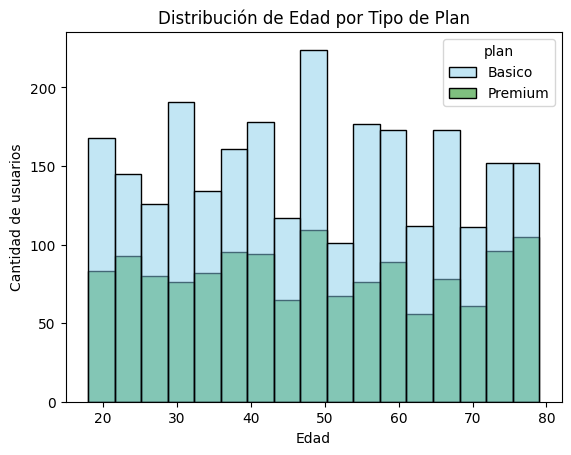

In [30]:
# Histograma para visualizar la edad (age)
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: Histograma de la edad por tipo de plan
Observaciones:
La distribución de edades es bastante uniforme tanto para los usuarios del plan Básico como del Premium.
El plan Básico presenta una mayor cantidad de usuarios en prácticamente todos los rangos de edad, lo cual es consistente con que este plan representa aproximadamente el 65% de la base de clientes.
No se observa que un grupo de edad específico prefiera claramente uno de los dos planes.
Las edades abarcan aproximadamente de 18 a 79 años, sin concentraciones extremas ni valores atípicos visibles.

Distribución:
Tipo de distribución: aproximadamente uniforme (sin sesgo marcado).
No se aprecia una distribución claramente simétrica ni una cola pronunciada hacia la derecha o izquierda.

La distribución de edades es similar entre los planes Básico y Premium. El plan Básico concentra un mayor número de usuarios debido a su mayor participación dentro de la cartera de clientes, pero no se identifica un patrón que relacione la edad con la elección del plan. La edad de los usuarios se distribuye de manera relativamente uniforme entre los 18 y 79 años, sin evidencia de sesgos importantes.

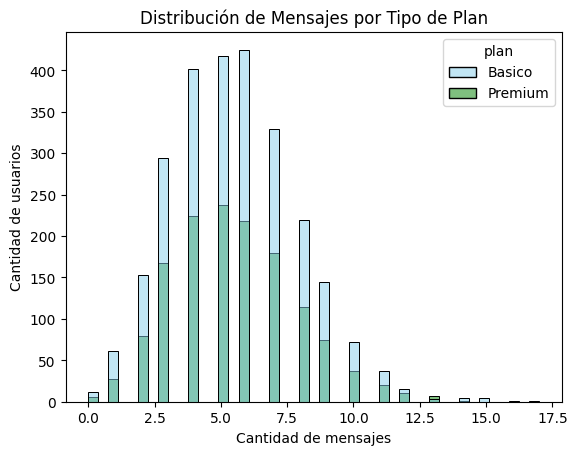

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: Distribución de Mensajes por Tipo de Plan

Observaciones:
La mayor concentración de usuarios, tanto del plan Básico como del Premium, se encuentra entre 4 y 7 mensajes enviados.
El plan Básico presenta una mayor cantidad de usuarios en casi todos los rangos de mensajes, lo cual es consistente con que representa aproximadamente el 65% de la base de clientes.
No se aprecia una diferencia significativa en el comportamiento de envío de mensajes entre ambos planes; las distribuciones tienen una forma muy similar.
Se observan pocos usuarios que envían más de 10 mensajes, formando una cola hacia la derecha.

Tipo de distribución:
La distribución es sesgada a la derecha (right-skewed), ya que la mayoría de los usuarios envía pocos mensajes y existe un número reducido de usuarios con una cantidad considerablemente mayor de mensajes.

La mayor parte de los usuarios de ambos planes envía entre 4 y 7 mensajes. No se observan diferencias importantes entre los planes Básico y Premium en cuanto al uso de mensajes; la principal diferencia es que el plan Básico concentra un mayor número de usuarios. La distribución presenta un sesgo a la derecha debido a la presencia de pocos usuarios con un volumen elevado de mensajes.


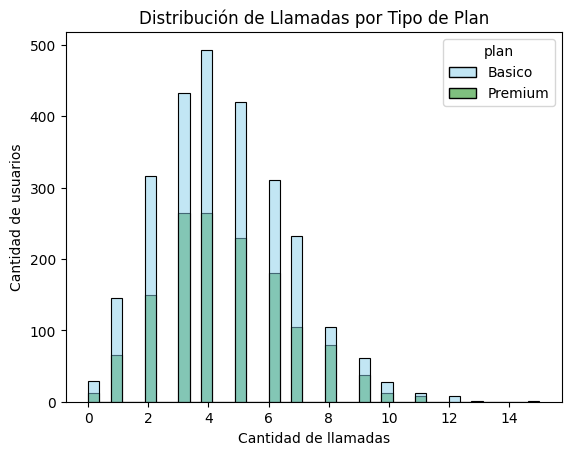

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: Distribución de Llamadas por Tipo de Plan

Observaciones: 
La mayor parte de los usuarios de ambos planes realiza entre 3 y 6 llamadas, donde se concentra la mayor frecuencia.
El plan Básico presenta un mayor número de usuarios en todos los rangos de llamadas, lo cual coincide con que representa aproximadamente el 65 % de la cartera de clientes.
Los usuarios de ambos planes muestran un comportamiento muy similar respecto a la cantidad de llamadas realizadas, sin diferencias importantes atribuibles al tipo de plan.
Se observa un grupo reducido de usuarios que realiza más de 10 llamadas, aunque su frecuencia es baja.

Tipo de distribución:
La distribución es sesgada a la derecha (right-skewed), ya que la mayoría de los usuarios realiza pocas llamadas y existe una cola formada por usuarios con un mayor número de llamadas.

La mayoría de los usuarios de los planes Básico y Premium realiza entre 3 y 6 llamadas. No se observan diferencias relevantes entre ambos planes en cuanto al número de llamadas realizadas; la principal diferencia corresponde al mayor número de clientes del plan Básico. La distribución presenta un sesgo a la derecha debido a la presencia de pocos usuarios con un volumen elevado de llamadas.


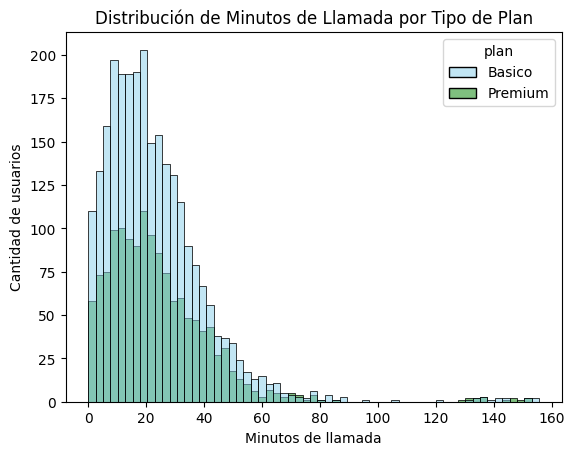

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: Distribución de Minutos de Llamada por Tipo de Plan

Observaciones:
La mayor parte de los usuarios de ambos planes consume entre 5 y 30 minutos de llamadas, concentrándose el mayor número de registros alrededor de los 15 a 20 minutos.
El plan Básico presenta una mayor frecuencia en casi todos los intervalos, lo cual es consistente con que representa la mayor parte de la base de clientes.
Ambos planes muestran un comportamiento de consumo muy similar durante la mayor parte de la distribución.
Se observa un pequeño grupo de usuarios que acumula más de 100 minutos, e incluso algunos cercanos a 150 minutos, lo que sugiere la presencia de valores extremos (outliers).

Tipo de distribución:
La distribución presenta un sesgo pronunciado hacia la derecha (right-skewed).
La mayoría de los usuarios consume pocos minutos, mientras que un número reducido registra consumos considerablemente más altos, generando una cola larga hacia la derecha.

La mayor parte de los usuarios de los planes Básico y Premium consume entre 5 y 30 minutos de llamadas, sin diferencias significativas entre ambos planes. La distribución presenta un marcado sesgo a la derecha debido a un pequeño grupo de usuarios con un consumo muy elevado de minutos, lo que sugiere la presencia de posibles valores atípicos que deberán analizarse en la etapa de detección de outliers.

Hasta este momento ya llevamos cuatro histogramas analizados:

Edad
Cantidad de mensajes
Cantidad de llamadas
Minutos de llamadas

En ninguno se observa una diferencia clara entre los usuarios del plan Básico y Premium. La principal diferencia visual es que el plan Básico tiene más observaciones porque representa aproximadamente el 65 % de los clientes.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

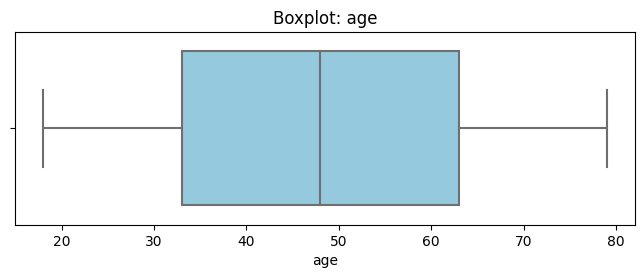

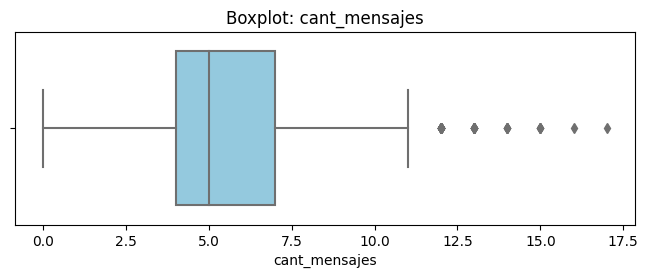

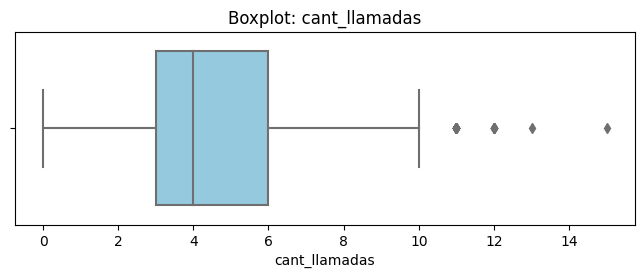

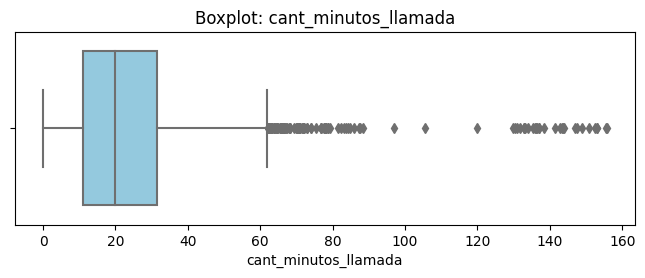

In [34]:
# Visualizando usando BoxPlot 

import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,2.5))
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: No se observan outliers. Después de reemplazar el valor sentinel -999 por la mediana, la edad queda comprendida entre 18 y 79 años, un rango completamente válido para clientes de una empresa de telecomunicaciones.
- cant_mensajes: No se observan outliers relevantes. La mayoría de los usuarios envía entre 4 y 7 mensajes, y aunque existen usuarios que alcanzan 17 mensajes, este valor no es excesivamente distante respecto a la distribución general.
- cant_llamadas: No se identifican outliers significativos. La mayor parte de los usuarios realiza entre 3 y 6 llamadas, mientras que el máximo de 15 llamadas continúa siendo un comportamiento razonable para el contexto del negocio.
- cant_minutos_llamada: Sí se observan outliers. Esta variable presenta valores considerablemente altos respecto al comportamiento típico de los usuarios. Aunque el 75% de los clientes consume hasta 31.42 minutos, existen registros que alcanzan 155.69 minutos, lo que indica una cola larga hacia la derecha y la presencia de valores atípicos.

In [35]:
# Calcular límites con el método IQR
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f'{col}')
    print(f'Límite superior: {limite_superior:.2f}')
    print()


cant_mensajes
Límite superior: 11.50

cant_llamadas
Límite superior: 10.50

cant_minutos_llamada
Límite superior: 61.86



In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- Aunque algunos usuarios envían más mensajes que la mayoría, estos registros representan un comportamiento válido de clientes con mayor uso del servicio y no evidencian errores de captura.
- cant_llamadas: mantener o no outliers, porqué?
- Mantener los outliers. Los usuarios con un número elevado de llamadas pueden corresponder a clientes con un patrón de uso intensivo. Estos valores aportan información relevante para el análisis del comportamiento de consumo.
- cant_minutos_llamada: mantener o no outliers, porqué?
- Mantener los outliers. Esta variable presenta los valores atípicos más pronunciados; sin embargo, es probable que correspondan a clientes con un consumo elevado de minutos. Al no existir indicios de errores en los datos, se recomienda conservarlos para no sesgar el análisis y facilitar la identificación de segmentos de alto consumo.

Comentarios: El método IQR identificó valores atípicos en cant_mensajes, cant_llamadas y cant_minutos_llamada, ya que sus valores máximos superan los límites superiores establecidos. No obstante, estos registros son consistentes con posibles clientes de alto consumo y no representan errores evidentes de captura. Por ello, se decidió conservarlos para el análisis, ya que constituyen información valiosa para identificar patrones de uso, segmentar clientes y generar recomendaciones comerciales.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
import numpy as np

user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

# Combinar la tabla agregada con el dataset de usuarios

user_profile = users.merge(usage_agg, on='user_id', how='left')

# Conservar únicamente la fecha
user_profile['reg_date'] = user_profile['reg_date'].dt.date

In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02,Basico,NaN,4.0,3.0,8.01


Comentario: Se creó la variable grupo_uso para clasificar a los usuarios según su nivel de consumo de llamadas y mensajes. La segmentación distingue tres niveles: Bajo uso, Uso medio y Alto uso, permitiendo identificar de forma sencilla diferentes patrones de comportamiento. Esta clasificación servirá como base para comparar el consumo entre segmentos y generar recomendaciones comerciales en los siguientes análisis.

In [39]:
# Distribución porcentual de los grupos de uso

import numpy as np

# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

# Distribución porcentual de los grupos de uso
(user_profile['grupo_uso']
 .value_counts(normalize=True)
 .mul(100)
 .round(2))

Uso medio    73.58
Bajo uso     19.45
Alto uso      6.98
Name: grupo_uso, dtype: float64

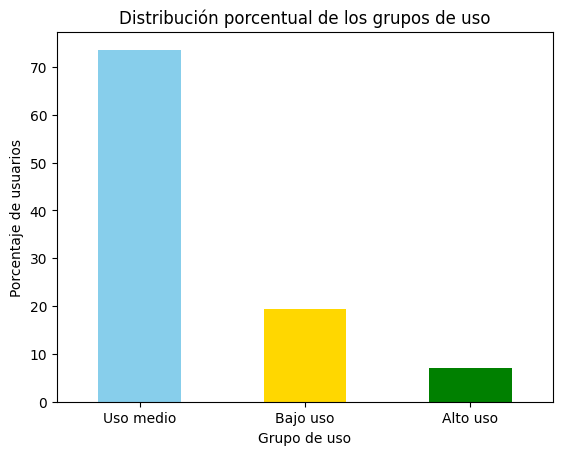

In [40]:
# Distribución porcentual de los grupos de uso

(user_profile['grupo_uso']
 .value_counts(normalize=True)
 .mul(100)
 .round(2)
 .plot(kind='bar', color=['skyblue', 'gold', 'green']))

plt.title('Distribución porcentual de los grupos de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Porcentaje de usuarios')
plt.xticks(rotation=0)
plt.show()

Comentario: La mayoría de los clientes (73.58 %) se concentra en el segmento de Uso medio, lo que indica un patrón de consumo moderado tanto en llamadas como en mensajes. El segmento de Bajo uso representa el 19.45 % de los usuarios, mientras que únicamente el 6.98 % pertenece al grupo de Alto uso, lo que sugiere que los clientes con un consumo intensivo constituyen una minoría.

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


In [43]:
# Distribución porcentual de los grupos de edad

(user_profile['grupo_edad']
 .value_counts(normalize=True)
 .mul(100)
 .round(2))

Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64

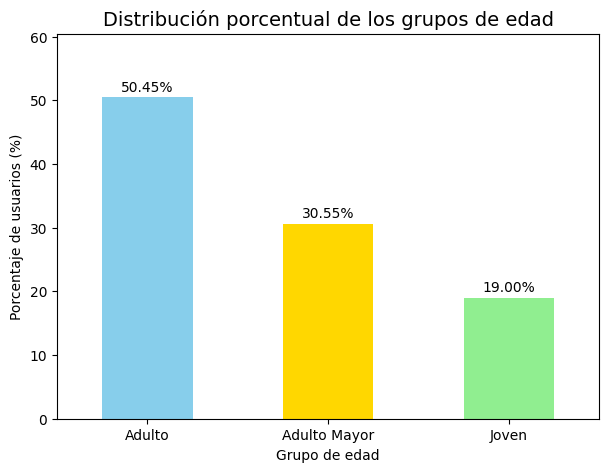

In [44]:
import matplotlib.pyplot as plt

# Calcular porcentajes
porcentajes = (
    user_profile['grupo_edad']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Crear gráfica
ax = porcentajes.plot(
    kind='bar',
    color=['skyblue', 'gold', 'lightgreen'],
    figsize=(7,5)
)

# Agregar porcentaje sobre cada barra
for i, valor in enumerate(porcentajes):
    ax.text(i, valor + 1, f'{valor:.2f}%', ha='center', fontsize=10)

# Personalizar gráfica
plt.title('Distribución porcentual de los grupos de edad', fontsize=14)
plt.xlabel('Grupo de edad')
plt.ylabel('Porcentaje de usuarios (%)')
plt.xticks(rotation=0)
plt.ylim(0, porcentajes.max() + 10)

plt.show()

Observaciones:

La mayor parte de los clientes pertenece al grupo de edad Adulto, seguido por Adulto Mayor. El segmento Joven representa la menor proporción de usuarios.

La distribución es asimétrica, ya que la mayor concentración de clientes se encuentra en el grupo Adulto y disminuye en los otros segmentos.

ConnectaTel cuenta principalmente con una base de clientes adultos. Este perfil puede orientar el diseño de campañas comerciales, planes de servicio y estrategias de retención dirigidas a las necesidades de este segmento, sin descuidar ofertas específicas para usuarios jóvenes y adultos mayores.

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

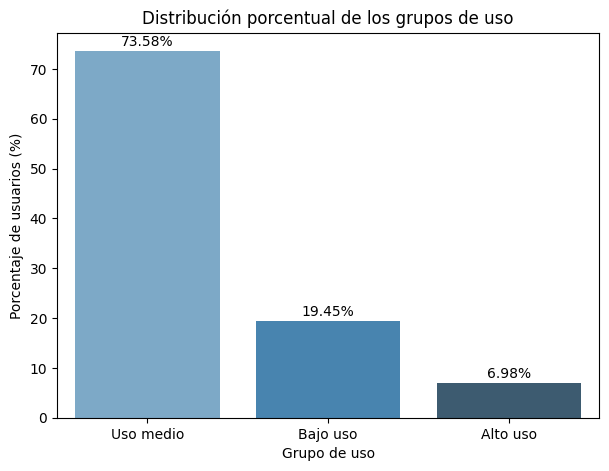

In [45]:
# Visualización de los segmentos por uso
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular porcentajes
uso_pct = (
    user_profile['grupo_uso']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

uso_pct.columns = ['grupo_uso', 'porcentaje']

# Gráfico
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=uso_pct,
    x='grupo_uso',
    y='porcentaje',
    palette='Blues_d'
)

# Agregar porcentaje sobre cada barra
for i, valor in enumerate(uso_pct['porcentaje']):
    ax.text(i, valor + 1, f'{valor:.2f}%', ha='center')

plt.title('Distribución porcentual de los grupos de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Porcentaje de usuarios (%)')

plt.show()

Observaciones:

La mayor parte de los usuarios pertenece al segmento de Uso medio, representando aproximadamente tres cuartas partes de la base de clientes. El grupo de Bajo uso constituye cerca de una quinta parte de los usuarios, mientras que el segmento de Alto uso representa una proporción reducida.

La distribución es asimétrica, con una clara concentración en el grupo de Uso medio y una menor participación en los extremos (Bajo uso y Alto uso).

Los resultados muestran que la mayoría de los clientes mantiene un nivel de consumo moderado de llamadas y mensajes. Esto representa una oportunidad para diseñar estrategias comerciales enfocadas en este segmento, mientras que los usuarios de alto consumo podrían beneficiarse de planes con mayores beneficios y los de bajo consumo de campañas para incrementar el uso de los servicios.

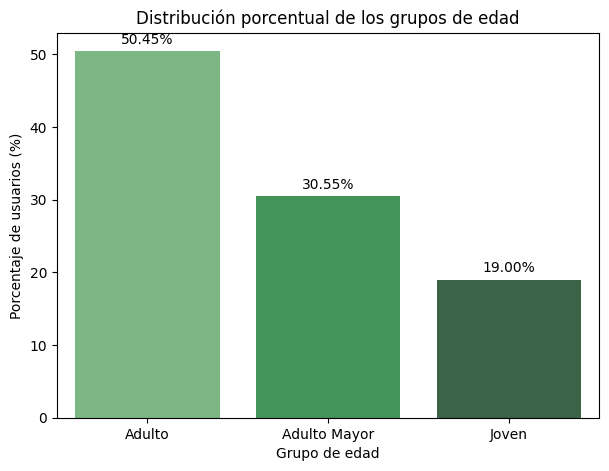

In [46]:
# Visualización de los segmentos por edad
# Calcular porcentajes
edad_pct = (
    user_profile['grupo_edad']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

edad_pct.columns = ['grupo_edad', 'porcentaje']

# Gráfico
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=edad_pct,
    x='grupo_edad',
    y='porcentaje',
    palette='Greens_d'
)

# Agregar porcentaje sobre cada barra
for i, valor in enumerate(edad_pct['porcentaje']):
    ax.text(i, valor + 1, f'{valor:.2f}%', ha='center')

plt.title('Distribución porcentual de los grupos de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Porcentaje de usuarios (%)')

plt.show()

Observaciones:

La base de clientes se concentra principalmente en el grupo Adulto, seguido por Adulto Mayor. El segmento Joven representa la menor proporción de usuarios.

La distribución es asimétrica, ya que existe una mayor concentración de usuarios adultos respecto a los demás grupos de edad.

ConnectaTel cuenta principalmente con clientes adultos, lo que sugiere que las estrategias comerciales, los planes y las campañas de fidelización deberían orientarse principalmente hacia este segmento. Sin embargo, también es recomendable desarrollar ofertas específicas para los grupos de jóvenes y adultos mayores, considerando sus diferentes patrones de consumo.


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Durante la exploración y limpieza de los datos se identificaron diversos problemas de calidad que podían afectar los resultados del análisis.
- La columna age contenía 40 registros (1.0%) con el valor sentinel -999, los cuales fueron reemplazados por la mediana de la edad para mantener una distribución representativa.
- La columna city presentaba 96 registros (2.4%) con el valor inválido "?", además de 469 valores nulos (11.73%). Estos registros se estandarizaron como valores nulos (NA) para evitar clasificaciones incorrectas.
- La columna churn_date contenía 3,534 valores nulos (88.35%). Este comportamiento es consistente con usuarios que permanecen activos, por lo que los valores se conservaron sin modificación.
- En reg_date se detectaron 40 fechas correspondientes al año 2026 (1.0%), fuera del periodo de análisis (hasta 2024). Estas fechas fueron reemplazadas por valores nulos.
- En usage, la columna date presentó únicamente 50 valores nulos (0.13%), mientras que duration (55.19%) y length (44.74%) contenían valores nulos que corresponden al tipo de actividad registrada (llamadas o mensajes), por lo que se confirmó que eran valores Missing At Random (MAR) y no fue necesario imputarlos.


🔍 **Segmentos por Edad**
- Los usuarios fueron clasificados en tres grupos:

Joven: menores de 30 años.
Adulto: entre 30 y 59 años.
Adulto Mayor: 60 años o más.

- El análisis muestra que la mayor parte de la base de clientes pertenece al segmento Adulto, seguido por Adulto Mayor, mientras que los usuarios jóvenes representan la menor proporción. Esto indica que la empresa atiende principalmente a clientes en edad laboral, quienes constituyen el mercado más representativo. 


📊 **Segmentos por Nivel de Uso**
- Los clientes fueron clasificados en tres categorías de acuerdo con su número de llamadas y mensajes:

Uso medio: 73.58 %
Bajo uso: 19.45 %
Alto uso: 6.98 %

- La mayor parte de los usuarios presenta un consumo moderado de los servicios móviles, mientras que los clientes de alto consumo representan un grupo reducido pero potencialmente estratégico para la empresa.

➡️ Esto sugiere que ConnectaTel cuenta con una base de clientes relativamente estable, cuyo comportamiento de consumo se concentra en niveles intermedios. Los usuarios de alto consumo podrían representar oportunidades para ofrecer planes con mayores beneficios, mientras que los usuarios de bajo consumo podrían beneficiarse de estrategias de activación o incentivos que incrementen el uso de los servicios.

📈 **Patrones de uso extremo (Outliers)**
El análisis mediante diagramas de caja y el método del rango intercuartílico (IQR) permitió identificar valores atípicos en:

Cantidad de mensajes.
Cantidad de llamadas.
Minutos acumulados de llamadas.

Estos valores extremos únicamente aparecen en la parte superior de las distribuciones y corresponden a usuarios con un consumo significativamente mayor al promedio. Debido a que representan posibles comportamientos reales de clientes intensivos y no errores de captura, se decidió conservarlos para el análisis.

Su presencia indica que existe un segmento reducido de clientes con necesidades de consumo superiores al promedio, lo que representa una oportunidad para diseñar productos especializados.


💡 **Recomendaciones**
- Con base en los resultados obtenidos, se proponen las siguientes acciones para ConnectaTel:
- Diseñar planes diferenciados para usuarios de alto consumo, ofreciendo mayores paquetes de minutos y mensajes a un costo competitivo.
- Implementar campañas de fidelización dirigidas al segmento de uso medio, ya que representa la mayor parte de la cartera de clientes.
- Desarrollar promociones específicas para usuarios de bajo uso, con el objetivo de incrementar la utilización de los servicios.
- Mantener un monitoreo continuo de los usuarios con consumos extremos para identificar oportunidades comerciales y detectar oportunamente posibles comportamientos anómalos o fraudes.
- Fortalecer los procesos de captura y validación de datos para evitar valores sentinels, fechas fuera de rango y registros inconsistentes en futuras actualizaciones de las bases de datos.


💡 **Valoración**
- Este análisis permitió construir un perfil confiable del comportamiento de los clientes de ConnectaTel, identificar segmentos con características diferenciadas y detectar oportunidades para optimizar la oferta comercial. Los resultados proporcionan información útil para apoyar la toma de decisiones relacionadas con el diseño de planes, la retención de clientes y la mejora continua de la calidad de los datos.




---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`